###  Data Loading

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install statsmodels

In [4]:
df = pd.read_csv("ab_experiment_users.csv")

In [5]:
print(df.shape)

(100000, 12)


In [57]:
df.tail()  

,user_id,experiment_group,device,traffic_source,age_group,view,click,add_to_cart,checkout,purchase,order_value,revenue
99995,99996,Control,Desktop,Paid Search,35-44,True,False,False,False,False,0.0,0.0
99996,99997,Variant,Mobile,Organic,18-24,True,False,False,False,False,0.0,0.0
99997,99998,Variant,Desktop,Paid Search,25-34,True,False,False,False,False,0.0,0.0
99998,99999,Control,Desktop,Organic,18-24,False,False,False,False,False,0.0,0.0
99999,100000,Variant,Desktop,Paid Search,35-44,True,False,False,False,False,0.0,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           100000 non-null  int64  
 1   experiment_group  100000 non-null  object 
 2   device            100000 non-null  object 
 3   traffic_source    100000 non-null  object 
 4   age_group         100000 non-null  object 
 5   view              100000 non-null  bool   
 6   click             100000 non-null  bool   
 7   add_to_cart       100000 non-null  bool   
 8   checkout          100000 non-null  bool   
 9   purchase          100000 non-null  bool   
 10  order_value       100000 non-null  float64
 11  revenue           100000 non-null  float64
dtypes: bool(5), float64(2), int64(1), object(4)
memory usage: 5.8+ MB


In [8]:
print(df.describe())  

             user_id    order_value        revenue
count  100000.000000  100000.000000  100000.000000
mean    50000.500000       6.669749       6.669749
std     28867.657797      23.210884      23.210884
min         1.000000       0.000000       0.000000
25%     25000.750000       0.000000       0.000000
50%     50000.500000       0.000000       0.000000
75%     75000.250000       0.000000       0.000000
max    100000.000000     300.000000     300.000000


In [9]:
print(df.isnull().sum())

user_id             0
experiment_group    0
device              0
traffic_source      0
age_group           0
view                0
click               0
add_to_cart         0
checkout            0
purchase            0
order_value         0
revenue             0
dtype: int64


In [10]:
# Unique values in categorical columns
print("Experiment groups:", df['experiment_group'].unique())
print("Devices:", df['device'].unique())
print("Traffic sources:", df['traffic_source'].unique())
print("Age groups:", df['age_group'].unique())

Experiment groups: ['Variant' 'Control']
Devices: ['Tablet' 'Mobile' 'Desktop']
Traffic sources: ['Paid Search' 'Direct' 'Social' 'Email' 'Organic']
Age groups: ['25-34' '45-54' '35-44' '55+' '18-24']


In [11]:
# funnel stage distribution
funnel_cols = ['view','click','add_to_cart','checkout','purchase']
print(df[funnel_cols].sum())   # total users at each stage

view           82655
click          47506
add_to_cart    24141
checkout       15270
purchase        9318
dtype: int64


### data cleaning

In [12]:
# categorical columns are standardized
df['experiment_group'] = df['experiment_group'].str.strip().str.title()
df['device'] = df['device'].str.strip().str.title()
df['traffic_source'] = df['traffic_source'].str.strip().str.title()
df['age_group'] = df['age_group'].str.strip()

In [13]:
# boolean columns are True/False
funnel_cols = ['view','click','add_to_cart','checkout','purchase']

for col in funnel_cols:
    df[col] = df[col].astype(bool)

In [14]:
# numeric columns are float
df['order_value'] = df['order_value'].astype(float)
df['revenue'] = df['revenue'].astype(float)

In [15]:
df.head()

,user_id,experiment_group,device,traffic_source,age_group,view,click,add_to_cart,checkout,purchase,order_value,revenue
0,1,Variant,Tablet,Paid Search,25-34,True,True,False,False,False,0.0,0.0
1,2,Control,Tablet,Paid Search,25-34,False,False,False,False,False,0.0,0.0
2,3,Variant,Mobile,Direct,45-54,True,False,False,False,False,0.0,0.0
3,4,Variant,Desktop,Social,45-54,True,False,False,False,False,0.0,0.0
4,5,Control,Mobile,Email,45-54,True,False,False,False,False,0.0,0.0


In [23]:
df.to_csv("ab_experiment_users_clean.csv", index=False)

In [27]:
pip install psycopg[binary] pandas

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pandas in c:\users\sneha\appdata\local\programs\python\python312\lib\site-packages (2.2.3)
   ---------------------------------------- 0.0/3.6 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/3.6 MB 4.2 MB/s eta 0:00:01
   ----------------- ---------------------- 1.6/3.6 MB 4.4 MB/s eta 0:00:01
   -------------------------- ------------- 2.4/3.6 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 3.6/3.6 MB 4.6 MB/s eta 0:00:00




[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### PostgreSQL Data Loading RUN ONLY ONCE

inserts the cleaned dataset into PostgreSQL.
Do NOT rerun this cell if the data has already been loaded.

In [37]:
import pandas as pd
import psycopg

df = pd.read_csv("ab_experiment_users_clean.csv")

with psycopg.connect(
    host="localhost",
    port=5432,
    dbname="ab_experiment_users_db",
    user="postgres",
    password="Sneha@40"
) as conn:

    with conn.cursor() as cur:
        with cur.copy("""
            COPY ab_experiment_users
            FROM STDIN
            WITH (FORMAT CSV, HEADER TRUE)
        """) as copy:
            copy.write(df.to_csv(index=False))

    conn.commit()

print("Data loaded successfully.")

UniqueViolation: duplicate key value violates unique constraint "ab_experiment_users_pkey"
DETAIL:  Key (user_id)=(1) already exists.
CONTEXT:  COPY ab_experiment_users, line 2

###  A/B Experimentation
Conversion → Uplift → Hypothesis → Z-test → P-value → Decision

In [16]:
control = df[df["experiment_group"] == "Control"]
variant = df[df["experiment_group"] == "Variant"]

print("Control users:", len(control))
print("Variant users:", len(variant))

Control users: 49743
Variant users: 50257


In [30]:
# Extract Control and Variant values
control_users = len(control)
variant_users = len(variant)

control_purchases = control["purchase"].sum()
variant_purchases = variant["purchase"].sum()

control_conversion = control_purchases / control_users
variant_conversion = variant_purchases / variant_users

print(f"Control Conversion Rate: {control_conversion:.2%}")
print(f"Variant Conversion Rate: {variant_conversion:.2%}")

Control Conversion Rate: 8.47%
Variant Conversion Rate: 10.16%


In [18]:
# conversion uplift
absolute_uplift = variant_conversion - control_conversion

relative_uplift = (
    (variant_conversion - control_conversion)
    / control_conversion
) * 100

print(f"Absolute Uplift: {absolute_uplift:.2%}")
print(f"Relative Uplift: {relative_uplift:.2f}%")

Absolute Uplift: 1.70%
Relative Uplift: 20.04%


### Hypothesis

**Null Hypothesis (H₀):**  
There is no difference in purchase conversion between Control and Variant.

**Alternative Hypothesis (H₁):**  
There is a difference in purchase conversion between Control and Variant.

**Significance Level:** 5% (α = 0.05)

In [24]:
from statsmodels.stats.proportion import proportions_ztest

In [31]:
#Two-proportion Z-test
count = np.array([variant_purchases,control_purchases])

nobs = np.array([variant_users,control_users])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.30f}")

Z-statistic: 9.2264
P-value: 0.000000000000000000027980115075


In [29]:
alpha = 0.05

if p_value < alpha:
    print("Statistically significant difference between Control and Variant.")
else:
    print("No statistically significant difference between Control and Variant.")

Statistically significant difference between Control and Variant.


In [32]:
if p_value < alpha and variant_conversion > control_conversion:
    print("Variant significantly outperforms Control.")

elif p_value < alpha and variant_conversion < control_conversion:
    print("Variant significantly underperforms Control.")

else:
    print("There is not enough statistical evidence to conclude that Variant is different from Control.")

Variant significantly outperforms Control.


In [35]:
#A/B test summary
ab_summary = pd.DataFrame({
    "Metric": ["Users", "Purchases", "Conversion Rate"],
    "Control": [control_users, control_purchases, control_conversion],
    "Variant": [variant_users, variant_purchases, variant_conversion]
})

display(ab_summary)

,Metric,Control,Variant
0,Users,49743.000000,50257.000000
1,Purchases,4211.000000,5107.000000
2,Conversion Rate,0.084655,0.101618


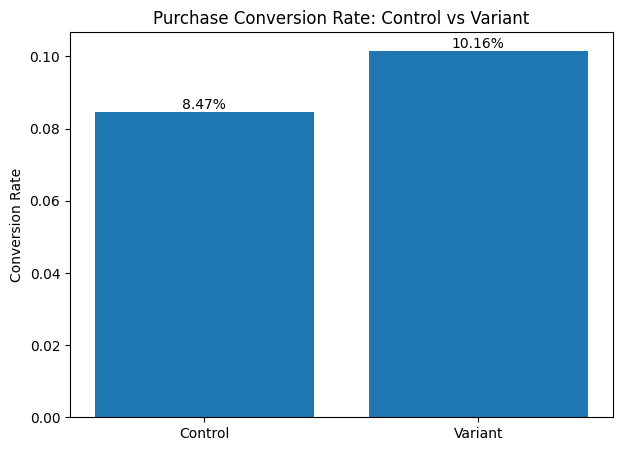

In [49]:
groups = ["Control", "Variant"]
conversion_rates = [control_conversion, variant_conversion]

plt.figure(figsize=(7, 5))

plt.bar(groups, conversion_rates)

plt.title("Purchase Conversion Rate: Control vs Variant")
plt.ylabel("Conversion Rate")

for i, value in enumerate(conversion_rates):
    plt.text(i, value, f"{value:.2%}", ha="center", va="bottom" )

plt.show()

### Visualization

In [39]:
import pandas as pd
import psycopg

conn = psycopg.connect(
    host="localhost",
    port=5432,
    dbname="ab_experiment_users_db",
    user="postgres",
    password="Sneha@40"
)

query = """
SELECT
    experiment_group,
    SUM(view::int) AS views,
    SUM(click::int) AS clicks,
    SUM(add_to_cart::int) AS add_to_cart,
    SUM(checkout::int) AS checkouts,
    SUM(purchase::int) AS purchases
FROM ab_experiment_users
GROUP BY experiment_group
ORDER BY experiment_group;
"""

with conn.cursor() as cur:
    cur.execute(query)
    rows = cur.fetchall()
    columns = [desc.name for desc in cur.description]

df_funnel = pd.DataFrame(rows, columns=columns)

conn.close()

display(df_funnel)

,experiment_group,views,clicks,add_to_cart,checkouts,purchases
0,Control,41135,23566,11646,7238,4211
1,Variant,41520,23940,12495,8032,5107


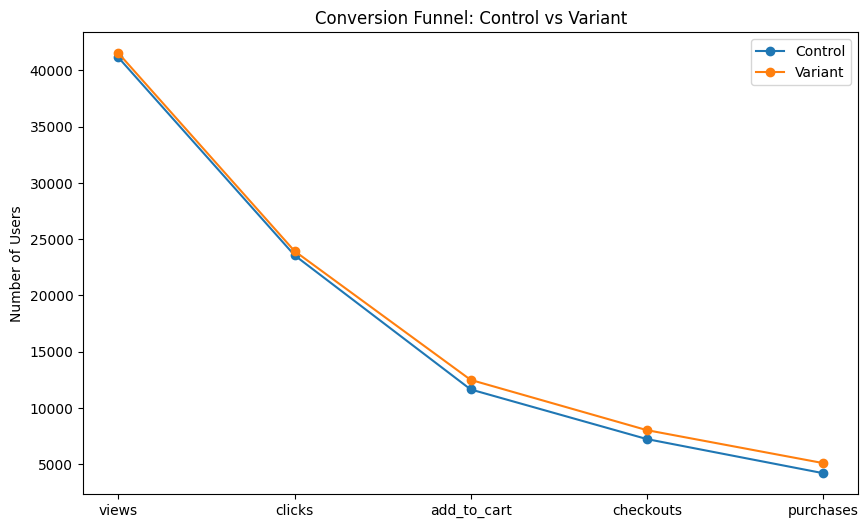

In [41]:
# Plot funnel comparison
stages = ['views','clicks','add_to_cart','checkouts','purchases']
fig, ax = plt.subplots(figsize=(10,6))
for group in df_funnel['experiment_group'].unique():
    values = df_funnel[df_funnel['experiment_group']==group][stages].values[0]
    ax.plot(stages, values, marker='o', label=group)

ax.set_title("Conversion Funnel: Control vs Variant")
ax.set_ylabel("Number of Users")
ax.legend()
plt.show()

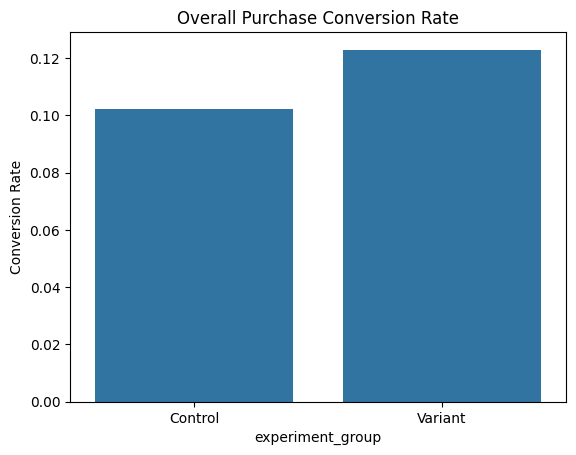

In [48]:
# Calculate conversion rates
df_funnel['overall_conversion_rate'] = df_funnel['purchases'] / df_funnel['views']

sns.barplot(x='experiment_group', y='overall_conversion_rate', data=df_funnel)
plt.title("Overall Purchase Conversion Rate")
plt.ylabel("Conversion Rate")
plt.show()


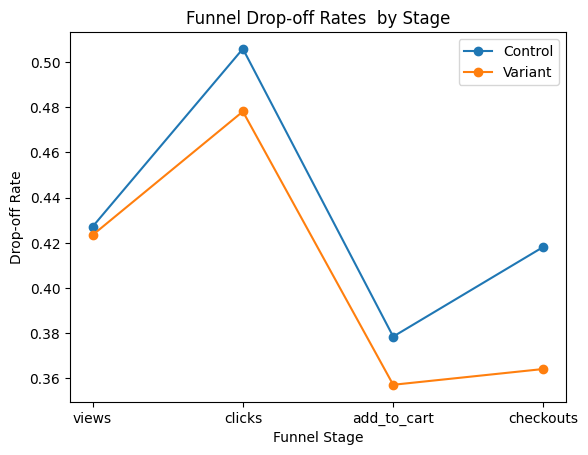

In [55]:
for group in df_funnel['experiment_group'].unique():
    values = df_funnel[df_funnel['experiment_group'] == group][stages].values[0]
    dropoffs = []

    for i in range(len(values) - 1):
        dropoffs.append(1 - values[i + 1] / values[i])

    plt.plot(stages[:-1], dropoffs, marker='o', label=group)

plt.title("Funnel Drop-off Rates  by Stage")
plt.xlabel("Funnel Stage")
plt.ylabel("Drop-off Rate")
plt.legend()
plt.show()